<a href="https://colab.research.google.com/github/Froststar16/canopy-watch-hyderabad/blob/main/notebooks/04_haritha_haram_overlay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Canopy Watch — Hyderabad
### Phase 4: Accountability overlay — Haritha Haram claims vs. satellite-measured canopy trend

**Scope note (read this first):** the original roadmap for this phase called for a ward-level
comparison, cross-checked against the Phase 3 heat-risk wards. Digging into what's actually
publicly available, official Haritha Haram plantation data for GHMC only exists in structured
form at the **city-wide** level, not per-ward — it's reported through the Telangana Forest
Department's FMIS system (fmis.telangana.gov.in), which treats GHMC as a single reporting unit
alongside the state's revenue districts. There's also an individual geo-tagged plantation site
viewer on that portal, but it's organised by forest Circle/Division/Range/Beat, not by GHMC's
155 civic wards, and it's a manual, form-driven export — no API.

So this notebook does the **city-wide accountability check**: does GHMC's own reported sapling
planting/survival data, year over year, show up as any measurable signal in the satellite NDVI
and LST record? Ward-level cross-referencing (Phase 4b) is left as a stretch goal — see the last
section.

This notebook:
1. Loads the existing city-wide NDVI trend (Phase 1/2) and derives a city-wide LST trend from
   the ward-level LST table (Phase 3)
2. Loads a provisional, press-sourced timeline of official planting claims (narrative context only —
   inconsistent metrics, not used in any calculation)
3. Loads the authoritative FMIS-sourced annual GHMC table (**you fill this in manually** — see
   Section 3 for exact steps) and plots it against the satellite trends
4. Runs a lagged correlation check between reported planting and NDVI change, with an explicit
   caveat about sample size and confounding factors

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

# NOTE: adjust this if your Phase 1-3 notebooks used a different Drive path convention
BASE_DIR = '/content/drive/MyDrive/canopy-watch-hyderabad'
OUTPUT_DIR = f'{BASE_DIR}/outputs'
DATA_DIR = f'{BASE_DIR}/data'

Mounted at /content/drive


## 2. Load the existing satellite trends

Re-using Phase 2's city-wide NDVI trend (real GHMC boundary) and Phase 3's ward-level LST table,
aggregated to a city-wide yearly mean.

In [2]:
ndvi_df = pd.read_csv(f'{OUTPUT_DIR}/hyderabad_ndvi_yearly_realboundary.csv')
print("NDVI columns:", list(ndvi_df.columns))
ndvi_df.head()

NDVI columns: ['year', 'mean_ndvi']


,year,mean_ndvi
0,2016,0.210383
1,2017,0.201310
2,2018,0.166410
3,2019,0.169390
4,2020,0.185212


In [3]:
lst_ward_df = pd.read_csv(f'{OUTPUT_DIR}/hyderabad_lst_by_ward.csv')
print("LST-by-ward columns:", list(lst_ward_df.columns))
lst_ward_df.head()

LST-by-ward columns: ['year', 'ward_no', 'mean_lst_c']


,year,ward_no,mean_lst_c
0,2016,127,39.698150
1,2016,119,39.052895
2,2016,145,41.159195
3,2016,146,41.510924
4,2016,147,40.433743


In [4]:
# Unweighted city-wide mean LST per year across all wards.
# NOTE: adjust the column names below if they don't match your Phase 3 output
# (e.g. 'ward_no' vs 'ward', 'mean_lst_c' vs 'lst_celsius')
year_col = 'year'
lst_col = [c for c in lst_ward_df.columns if 'lst' in c.lower()][0]
print(f"Using LST column: {lst_col}")

lst_city_df = (
    lst_ward_df.groupby(year_col)[lst_col]
    .mean()
    .reset_index()
    .rename(columns={lst_col: 'mean_lst_c'})
)
lst_city_df

Using LST column: mean_lst_c


,year,mean_lst_c
0,2016,39.945044
1,2017,38.167553
2,2018,38.520211
3,2019,39.685919
4,2020,37.781437
5,2021,38.808839
6,2022,37.596315
7,2023,38.130877
8,2024,37.134787
9,2025,36.486037


## 3. Haritha Haram data — the reality check

### 3a. Provisional claims timeline (narrative context, not analysis-grade)

These are press-reported figures compiled from GHMC/government statements over the years. They
mix targets, achieved counts, nursery stock, single-day counts, and cumulative-to-date totals —
**do not treat this as a clean annual series**. It's useful for the README narrative ("here's what
officials have claimed over the years") but not for any correlation math.

In [6]:
claims_df = pd.read_csv(f'{DATA_DIR}/haritha_haram_claims_timeline.csv')
claims_df

,year,claim_metric,claim_value,claim_value_units,context,source_name,source_url
0,2016,spend,21.000,crore_rupees,GHMC spending on plantation as part of statewi...,TheNewsMinute,https://www.thenewsminute.com/telangana/harith...
1,2016,single_day_planted,25.000,lakh_saplings,Reported single-day citywide planting count on...,TheNewsMinute,https://www.thenewsminute.com/telangana/harith...
2,2017,achieved_FY17,84.910,lakh_saplings,"GHMC commissioner statement, planted against a...",Deccan Chronicle (Pressreader),https://www.pressreader.com/india/deccan-chron...
3,2018,target,100.000,lakh_saplings,"1 crore saplings planned for 2017-18 season, n...",Deccan Chronicle (Pressreader),https://www.pressreader.com/india/deccan-chron...
4,2019,achieved_snapshot,10.837,lakh_saplings,Mid-season snapshot (specific date in reportin...,The Hans India,https://www.thehansindia.com/telangana/ghmc-hm...
5,2020,target,250.000,lakh_saplings,Phase 6 target announced by GHMC Mayor; ward-w...,Etemaad Daily,https://www.en.etemaaddaily.com/world/hyderaba...
6,2020,target_alt,50.000,lakh_saplings,A separate GHMC announcement the same year cit...,Etemaad Daily,https://www.en.etemaaddaily.com/world/hyderaba...
7,2022,nursery_stock,190.000,lakh_saplings,Saplings raised and ready in GHMC's 600 nurser...,Etemaad Daily,https://www.en.etemaaddaily.com/world/hyderaba...
8,2023,target,100.000,lakh_saplings,TKHH 2023 plant/distribute target announced fo...,Telangana Today,https://telanganatoday.com/ghmc-to-plant-1-cro...
9,2023,cumulative_to_date,106.000,lakh_saplings,Cumulative saplings raised across 164 Haritha ...,NewsMeter,https://newsmeter.in/hyderabad/telangana-green...


### 3b. Authoritative FMIS data — fill this in manually

The Telangana Forest Department's FMIS portal has the real numbers, but it's a session-based
report viewer with no public API, so this has to be pulled by hand. Steps:

1. Go to **https://fmis.telangana.gov.in/DashboardReports/DashBoardHome.aspx**
2. In the left menu, open **District Action Plan → District Wise Target and Achievement**.
   Select each year (2016–2025 as available), find the row for **GHMC** (it's reported as its
   own unit, separate from the revenue districts), and note the target and achieved sapling
   counts. Use the report toolbar's export button (CSV/Excel/PDF) if it works for you — otherwise
   copy the numbers by hand.
3. Also open **Plantation Monitoring → District Wise Survival - Abstract**, same process, to get
   GHMC's reported survival percentage per year if available. This is arguably the more honest
   accountability metric — a high "planted" count means little if survival is low, which is
   exactly the gap the state's own 2019 Forest Survey findings and independent reporting have
   flagged before.
4. Fill in `data/haritha_haram_ghmc_annual.csv` (already scaffolded with year rows 2016–2025 and
   `target_saplings` / `achieved_saplings` / `survival_pct` / `source_report` / `notes` columns).
   Leave a year blank if the portal doesn't have it — don't guess.
5. Re-upload the filled CSV to your Drive `data/` folder and re-run the cell below.

If the portal turns out to be broken, paywalled, or laid out differently than expected, tell me
what you're seeing and we'll adjust — worst case this becomes an RTI request instead, which is a
legitimate (if slower) route for this kind of project.

In [7]:
hh_df = pd.read_csv(f'{DATA_DIR}/haritha_haram_ghmc_annual.csv')
filled_years = hh_df.dropna(subset=['achieved_saplings']).shape[0]
print(f"{filled_years} of {len(hh_df)} years have an 'achieved_saplings' value filled in.")
hh_df

0 of 10 years have an 'achieved_saplings' value filled in.


,year,target_saplings,achieved_saplings,survival_pct,source_report,notes
0,2016,NaN,NaN,NaN,NaN,NaN
1,2017,NaN,NaN,NaN,NaN,NaN
2,2018,NaN,NaN,NaN,NaN,NaN
3,2019,NaN,NaN,NaN,NaN,NaN
4,2020,NaN,NaN,NaN,NaN,NaN
5,2021,NaN,NaN,NaN,NaN,NaN
6,2022,NaN,NaN,NaN,NaN,NaN
7,2023,NaN,NaN,NaN,NaN,NaN
8,2024,NaN,NaN,NaN,NaN,NaN
9,2025,NaN,NaN,NaN,NaN,NaN


## 4. Combined visualization

City-wide NDVI, city-wide LST, and reported sapling planting on a shared timeline. Only plots
years where the FMIS data has been filled in.

No FMIS sapling data filled in yet -- plotting NDVI and LST only. Fill in data/haritha_haram_ghmc_annual.csv and re-run for the full overlay.


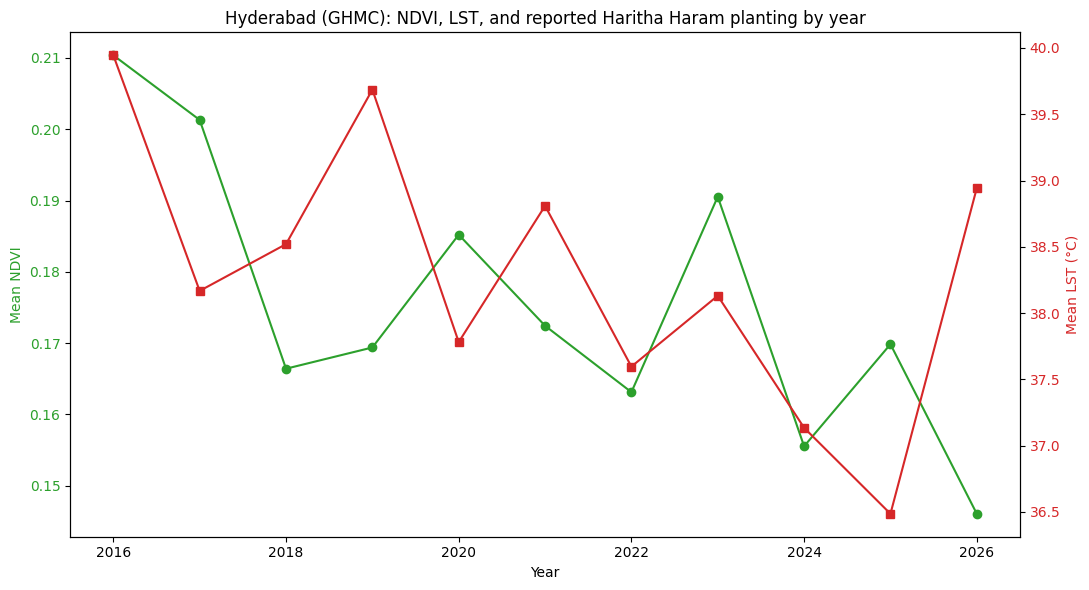

In [8]:
merged = (
    ndvi_df.merge(lst_city_df, on='year', how='inner')
    .merge(hh_df, on='year', how='left')
)

fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(merged['year'], merged['mean_ndvi'], color='tab:green', marker='o', label='Mean NDVI')
ax1.set_xlabel('Year')
ax1.set_ylabel('Mean NDVI', color='tab:green')
ax1.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax1.twinx()
ax2.plot(merged['year'], merged['mean_lst_c'], color='tab:red', marker='s', label='Mean LST (°C)')
ax2.set_ylabel('Mean LST (°C)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

has_hh_data = merged['achieved_saplings'].notna().any()
if has_hh_data:
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.bar(merged['year'], merged['achieved_saplings'], color='tab:brown', alpha=0.3,
            label='Saplings achieved (FMIS)')
    ax3.set_ylabel('Saplings achieved', color='tab:brown')
    ax3.tick_params(axis='y', labelcolor='tab:brown')
else:
    print("No FMIS sapling data filled in yet -- plotting NDVI and LST only. "
          "Fill in data/haritha_haram_ghmc_annual.csv and re-run for the full overlay.")

plt.title('Hyderabad (GHMC): NDVI, LST, and reported Haritha Haram planting by year')
fig.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/haritha_haram_overlay.png', dpi=150)
plt.show()

## 5. Lagged correlation check

Canopy from a planted sapling doesn't show up in NDVI the same year — it takes years to mature
into anything visible from Sentinel-2. This checks correlation between reported planting in year
Y and NDVI in years Y, Y+1, and Y+2.

**Caveat, stated plainly:** with roughly 10 annual data points at most, any correlation here is
illustrative, not statistically robust — treat it as a prompt for discussion, not a proven
relationship. NDVI also reflects *all* vegetation change citywide (private landscaping, other
afforestation efforts, seasonal variation, construction-driven loss), not just Haritha Haram
plantings specifically, so a weak or absent correlation doesn't disprove impact and a positive one
doesn't prove it either.

In [9]:
hh_valid = hh_df.dropna(subset=['achieved_saplings'])[['year', 'achieved_saplings']]

if len(hh_valid) < 4:
    print(f"Only {len(hh_valid)} years of FMIS data available -- too few for a meaningful "
          "correlation. Fill in more years from the FMIS portal and re-run.")
else:
    for lag in [0, 1, 2]:
        shifted_ndvi = ndvi_df.copy()
        shifted_ndvi['year'] = shifted_ndvi['year'] - lag  # align NDVI(Y+lag) with planting(Y)
        joined = hh_valid.merge(shifted_ndvi, on='year', how='inner')
        if len(joined) >= 4:
            r, p = stats.pearsonr(joined['achieved_saplings'], joined['mean_ndvi'])
            print(f"Lag {lag} yr (n={len(joined)}): r={r:.2f}, p={p:.3f}")
        else:
            print(f"Lag {lag} yr: not enough overlapping years (n={len(joined)})")

Only 0 years of FMIS data available -- too few for a meaningful correlation. Fill in more years from the FMIS portal and re-run.


## 6. Limitations

- **Self-reported by the agency being evaluated.** FMIS "achieved" counts come from the same
  Forest Department running the program — there's no independent audit built into this dataset.
- **Planted ≠ survived ≠ contributes to measurable canopy.** This is the core of the accountability
  question. Use the `survival_pct` column if you managed to source it — it's a stronger signal
  than raw planting counts.
- **No ward-level granularity.** This can't localize claims to the Phase 3 heat-risk wards. See
  Phase 4b below for what a ward-level version would require.
- **NDVI is a citywide aggregate confounded by everything else changing the city's vegetation**,
  not an isolated measure of this one program's effect.
- **Small n.** At most ~10 annual points. Any correlation is suggestive, not conclusive.

## Phase 4b (stretch goal, optional) — ward-level cross-check

If you want to push toward the original ward-level vision:

1. On FMIS, try **Plantations → Progress - Entered Site Wise → View Individual Plantation
   Details** — this has a GPS/Non-GPS filter and an Excel export for individual geo-tagged
   plantation sites. It's organised by forest Circle/Division/Range/Beat rather than GHMC wards,
   so first figure out which Division(s) cover GHMC's extent.
2. Export the GPS-tagged sites for the years you care about.
3. Load the site lat/lon points into GeoPandas and spatially join them against the same 155-ward
   `wards_ee` polygons from Phase 2 (`gpd.sjoin`) to get a per-ward site count.
4. Cross-reference against the Phase 3 `hyderabad_heat_risk_wards.csv` shortlist: are the
   worst-performing wards for canopy decline / heat rise actually getting proportionally more or
   fewer plantation sites?
5. If FMIS's site data turns out to be sparse, incomplete, or doesn't cover GHMC well, an RTI
   request to GHMC's Urban Biodiversity wing for ward-wise Haritha Haram figures is a legitimate
   (if slower) fallback — and the fact that this had to be requested rather than published is
   itself worth a line in the README.